# Hot Carrier Spatial Distribution — `HC_spatial.py`

This notebook demonstrates how to compute and visualise the **spatial distribution of photogenerated hot carriers** inside plasmonic nanoparticles using `plytrons.HC_spatial`.

It covers two geometries:

| Part | System | Key physics |
|---|---|---|
| **Part 1 — Single sphere** | Isolated Ag sphere, D = 5 nm | Polarisation-driven angular anisotropy |
| **Part 2 — Dimer** | Ag homodimer, D = 5 nm, gap = 1 nm | Gap-induced multipole loading, surface concentration |

---

## Key formula

$$n_e(r) = \sum_f \dot{N}_e[f] \; |A_f|^2 \, |j_{\ell_f}(k_f r)|^2 \, r^2$$

$$\rho_e(r,\theta) = \sum_{f, m_f} \dot{N}_e[f,m_f] \; |A_f|^2 \, |j_{\ell_f}(k_f r)|^2 \, |Y_{\ell_f m_f}(\theta)|^2$$

## Step 0 — Imports

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar as hbar_si, eV as eV_si, speed_of_light
from scipy.signal import find_peaks

# BCM solver
import plytrons.bcm_sphere as bcm
from plytrons.bcm_sphere import EField, BCMObject

# Quantum-well bound states
import plytrons.quantum_well as qw

# Spatial distribution (the new module)
from plytrons.HC_spatial import (
    hot_e_dist_spatial,
    hot_e_density_2d,
    plot_radial_profile,
    plot_2d_density,
)

# Silence harmless Numba safety warnings
from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter('ignore', category=NumbaTypeSafetyWarning)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

---
# Part 1 — Single Silver Sphere

Isolated Ag nanosphere, D = 5 nm. Demonstrates angle-averaged radial profiles, full 2-D polar maps, and polarisation-driven anisotropy.

---
## Step 1 — Build the system: single silver sphere

We use the **Boundary-Charge Method (BCM)** to compute the optical response of a small silver sphere.
The BCM expands the internal field in spherical harmonics $X_{\ell m}$ — these are the same coefficients that appear in the hot-carrier matrix element.

Parameters chosen:
- Diameter $D = 5$ nm
- Silver Drude model: $\hbar\omega_p = 9.07$ eV, $\hbar\gamma = 0.060$ eV, $\varepsilon_b = 4.18$
- $\ell_{\max} = 6$ (sufficient for a small sphere)
- Host medium: vacuum ($\varepsilon_h = 1$)
- Incident field: $E_0 = 1$ V/nm, propagating along $\hat{z}$, polarised along $\hat{x}$

In [2]:
# ── Material & geometry ────────────────────────────────────────────────────
D    = 5.0          # sphere diameter [nm]
a    = D / 2        # sphere radius   [nm]
lmax = 6            # max spherical-harmonic order
eps_h = 1.0         # host permittivity

# Drude parameters (silver)
wp_rad = 9.07  * eV_si / hbar_si   # plasma  frequency [rad/s]
gw_rad = 0.060 * eV_si / hbar_si   # damping rate      [rad/s]
eps_b  = 4.18                       # background permittivity

def eps_drude(lam_um):
    """Drude permittivity as a function of wavelength [µm]."""
    omega = 2 * np.pi * 3e14 / lam_um   # angular frequency [rad/s]  (c in µm/s)
    return eps_b - wp_rad**2 / (omega * (omega + 1j * gw_rad))

# ── Incident field ─────────────────────────────────────────────────────────
efield = EField(
    E0    = 1.0,
    k_hat = bcm.v_normalize([0, 0, 1]),   # propagation along z
    e_hat = bcm.v_normalize([1, 0, 0]),   # polarisation along x
)

# ── BCM object ─────────────────────────────────────────────────────────────
sphere = BCMObject(
    label    = 'Ag',
    diameter = D,
    lmax     = lmax,
    eps      = eps_drude,
    position = np.array([0.0, 0.0, 0.0]),
)
BCM_objects = [sphere]
print(f'Single silver sphere: D = {D} nm,  a = {a} nm,  lmax = {lmax}')

Single silver sphere: D = 5.0 nm,  a = 2.5 nm,  lmax = 6


---
## Step 2 — Solve the BCM over a frequency sweep

We sweep photon energies from 2.5 to 5.5 eV and solve the BCM at each frequency to get:
- The absorption cross-section $Q_{\mathrm{abs}}(\omega)$
- The internal field coefficients $X_{\ell m}(\omega)$ stored on the BCM object

In [3]:
# ── Frequency axis ─────────────────────────────────────────────────────────
w       = np.linspace(2.5, 5.5, 3000) * eV_si / hbar_si   # [rad/s]
lam_um  = 2 * np.pi * 3e14 / w                             # [µm]
hv_axis = w * hbar_si / eV_si                               # [eV]

# ── Pre-compute BCM matrices (frequency-independent) ───────────────────────
Gi  = [bcm.Ginternal(sphere)]
G0  = [[bcm.Gexternal(sphere, sphere)]]
Sv  = [bcm.Efield_coupling(sphere, efield)]

# ── Frequency loop ─────────────────────────────────────────────────────────
dx_max  = lmax * (lmax + 1) + (lmax + 1) - 1
coef    = np.zeros((dx_max, len(w)), dtype=complex)

for il, wi in enumerate(w):
    c, _ = bcm.solve_BCM(wi, eps_h, BCM_objects, efield, Gi, G0, Sv)
    coef[:, il] = c[0]

sphere.set_coefficients(lam_um, coef)

# ── Absorption power ───────────────────────────────────────────────────────
_, Pabs_all = bcm.EM_power(w, eps_h, Gi, G0, BCM_objects)

from scipy.constants import physical_constants
Z0 = physical_constants['characteristic impedance of vacuum'][0] * eV_si  # Ω in eV·s/e²
Qabs = Pabs_all[0] / (efield.E0**2 / (2 * Z0)) / (np.pi * a**2)

print('Frequency sweep done.')
print(f'Peak Qabs = {Qabs.max():.3f}')

Frequency sweep done.
Peak Qabs = 5.453


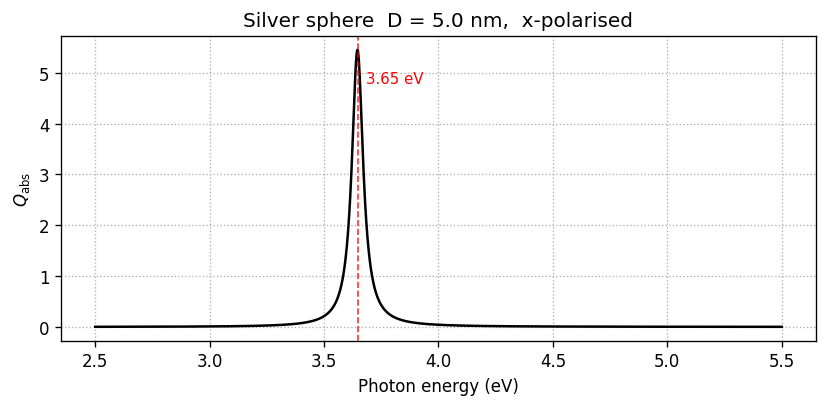

Absorption peaks at: ['3.646 eV']


In [4]:
# ── Plot absorption spectrum ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(hv_axis, Qabs, 'k', lw=1.5)
ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$Q_{\mathrm{abs}}$')
ax.set_title(f'Silver sphere  D = {D} nm,  x-polarised')
ax.grid(True, ls=':')

# Mark the peak
peaks_idx, _ = find_peaks(Qabs, height=0.1)
for pk in peaks_idx:
    ax.axvline(hv_axis[pk], ls='--', lw=1, color='r', alpha=0.8)
    ax.annotate(f'{hv_axis[pk]:.2f} eV', xy=(hv_axis[pk], Qabs[pk]),
                xytext=(5, -20), textcoords='offset points',
                color='r', fontsize=9)

fig.tight_layout()
plt.show()
print('Absorption peaks at:', [f'{hv_axis[p]:.3f} eV' for p in peaks_idx])

---
## Step 3 — Quantum-well bound states

Electrons in a metallic nanoparticle are confined in a **spherical quantum well** of radius $a$.  
The bound states are labelled $(n, \ell)$ where:
- $n$ = radial quantum number (number of nodes in $j_\ell(k r)$ inside the sphere)
- $\ell$ = angular momentum quantum number

Each $(n, \ell)$ state has energy $E_{n\ell}$ and radial normalization $A_{n\ell}$ such that
$$\int_0^a |A_{n\ell}|^2 |j_\ell(k_{n\ell} r)|^2 r^2 \, \mathrm{d}r = 1$$

The Fermi energy $E_F = 5.5$ eV is the chemical potential of silver.

In [5]:
EF = 5.5  # Fermi energy of silver [eV]

E_matrix = qw.get_bound_states(a)
A_matrix = qw.get_normalization(a, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

lmax_qw = len(e_states)
N_total  = sum(e_states[l].Eb.size for l in range(lmax_qw))
print(f'Quantum-well states: lmax = {lmax_qw-1},  total (n,l) levels = {N_total}')
print(f'Fermi energy: EF = {EF} eV')
print()

# Show a summary table of the lowest states
print(f'{"l":>4}  {"n":>4}  {"E [eV]":>10}  {"above EF":>10}')
print('-' * 38)
for l in range(min(lmax_qw, 4)):
    for n, E in enumerate(e_states[l].Eb.real):
        tag = '← hot carrier' if E > EF else ''
        print(f'{l:>4}  {n:>4}  {E:>10.3f}  {tag}')

Quantum-well states: lmax = 42,  total (n,l) levels = 296
Fermi energy: EF = 5.5 eV

   l     n      E [eV]    above EF
--------------------------------------
   0     0       0.060  
   0     1       0.241  
   0     2       0.541  
   0     3       0.963  
   0     4       1.504  
   0     5       2.166  
   0     6       2.948  
   0     7       3.850  
   0     8       4.873  
   0     9       6.016  ← hot carrier
   0    10       7.279  ← hot carrier
   0    11       8.663  ← hot carrier
   0    12      10.167  ← hot carrier
   0    13      11.792  ← hot carrier
   0    14      13.536  ← hot carrier
   1     0       0.123  
   1     1       0.364  
   1     2       0.725  
   1     3       1.206  
   1     4       1.808  
   1     5       2.530  
   1     6       3.372  
   1     7       4.334  
   1     8       5.417  
   1     9       6.621  ← hot carrier
   1    10       7.944  ← hot carrier
   1    11       9.388  ← hot carrier
   1    12      10.952  ← hot carrier
   1    13 

---
## Step 4 — Radial hot-carrier profile at the plasmon resonance

We pick the dominant absorption peak and compute the **angle-averaged radial density**.

### What does this tell us?

The radial density $n_e(r)$ answers: *how many hot electrons per unit radius are generated at radius $r$?*

- A peak near $r = a$ (surface) means the hot carriers are generated close to the interface — ideal for injection.
- A uniform or core-peaked profile means more carriers are deep inside and harder to extract.
- High-$\ell$ states (large angular momentum) have radial wavefunctions that are suppressed near the origin and enhanced near the surface — they contribute **surface-peaked** density.
- Low-$\ell$, low-$n$ states fill the core.

In [6]:
from plytrons.math_utils import eps0   # project's eps0 [eV/(V² nm)]

# ── Pick the main resonance ────────────────────────────────────────────────
if len(peaks_idx) == 0:
    pk_idx = Qabs.argmax()
else:
    pk_idx = peaks_idx[np.argmax(Qabs[peaks_idx])]

lam_peak  = lam_um[pk_idx]                         # [µm]
hv_peak   = hv_axis[pk_idx]                        # [eV]
X_lm      = sphere.coef_at(lam_peak)              # BCM multipole coefficients at resonance
Pabs_peak = Pabs_all[0][pk_idx] / (np.pi * eps0) * 1e-15   # [eV/fs]

print(f'Resonance: hv = {hv_peak:.3f} eV  (λ = {lam_peak*1e3:.1f} nm)')
print(f'Pabs at peak: {Pabs_peak:.4g} eV/fs')

# ── Lifetime ───────────────────────────────────────────────────────────────
tau_fs = 500.0   # inelastic lifetime [fs]

Resonance: hv = 3.646 eV  (λ = 340.3 nm)
Pabs at peak: 5109 eV/fs


In [7]:
# ── Compute angle-averaged radial density ─────────────────────────────────
r, n_e_r, n_h_r, rho_e_r, rho_h_r, E_states, Te_raw, Th_raw = hot_e_dist_spatial(
    a_nm    = a,
    hv_eV   = hv_peak,
    E_F     = EF,
    tau_fs  = tau_fs,
    e_state = e_states,
    X_lm    = X_lm,
    Pabs    = Pabs_peak,
    Nr      = 300,
)

# Quick check: integral of n_e(r) should equal sum of Te_raw
dr    = r[1] - r[0]
total_from_integral = np.trapz(n_e_r, r)
total_from_sum      = Te_raw.sum()
print(f'∫ n_e(r) dr  = {total_from_integral:.4g} fs⁻¹')
print(f'Σ Te_raw[f]  = {total_from_sum:.4g} fs⁻¹')
print(f'Ratio (should be ≈1): {total_from_integral/total_from_sum:.4f}')

c:\users\pablo\proyectos\plytrons\plytrons\hot_carriers.py:225: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi_2_block = _M_transition_squared(lf, li, a_nm, X_lm, state_lf, state_li)
c:\users\pablo\proyectos\plytrons\plytrons\hot_carriers.py:225: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi_2_block = _M_transition_squared(lf, li, a_nm, X_lm, state_lf, state_li)


∫ n_e(r) dr  = 1620 fs⁻¹
Σ Te_raw[f]  = 1620 fs⁻¹
Ratio (should be ≈1): 1.0000


c:\users\pablo\proyectos\plytrons\plytrons\HC_spatial.py:123: NumbaWarning: Cannot cache compiled function "_radial_density_kernel" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @nb.njit(cache=True, fastmath=True)


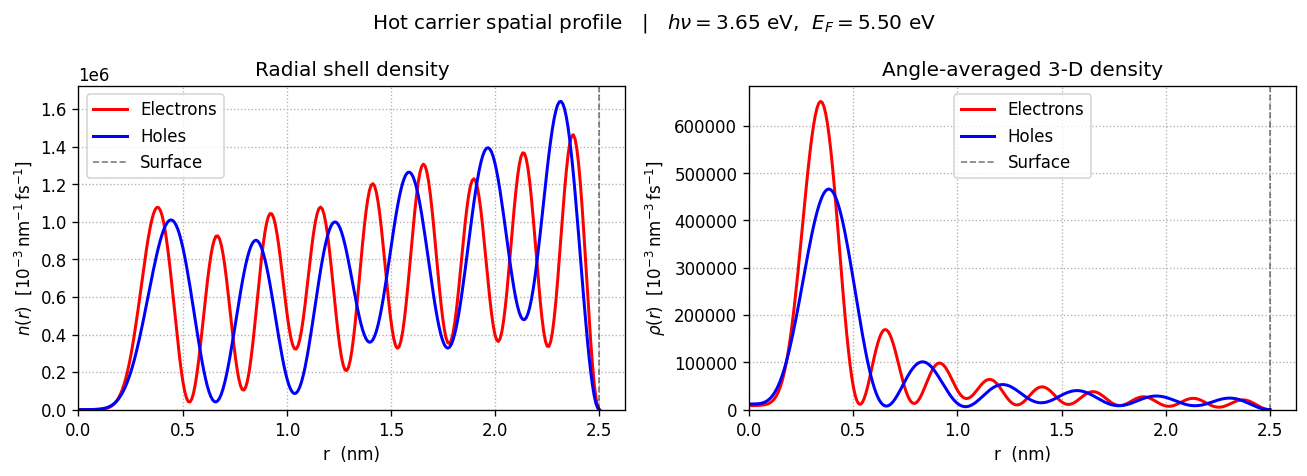

In [8]:
# ── Plot radial profile ────────────────────────────────────────────────────
fig, axes = plot_radial_profile(
    r, n_e_r, n_h_r, rho_e_r, rho_h_r,
    a_nm  = a,
    E_F   = EF,
    hv_eV = hv_peak,
)
plt.show()

---
### Breakdown by state: who contributes where?

We can decompose $n_e(r)$ by angular momentum $\ell$ to see which states dominate at different radii.

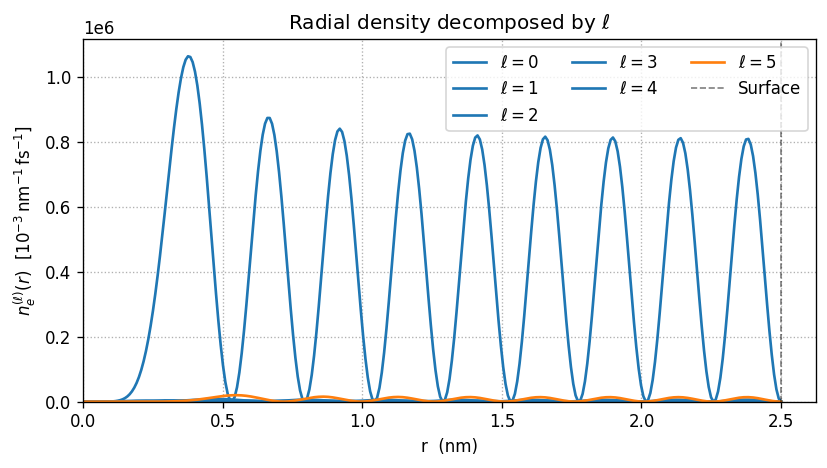

In [9]:
import plytrons.quantum_well as qw_mod

lmax_qw = len(e_states)

# Build l-ordered state map (same ordering as hot_e_dist_spatial returns)
E_lorder, l_lorder, A2_lorder = [], [], []
for l in range(lmax_qw):
    for n in range(e_states[l].Eb.size):
        E_lorder.append(float(e_states[l].Eb[n].real))
        l_lorder.append(l)
        A = e_states[l].A[n]
        A2_lorder.append(float((A * A.conj()).real))

E_lorder  = np.array(E_lorder)
l_lorder  = np.array(l_lorder, dtype=int)
A2_lorder = np.array(A2_lorder)

# Per-l contribution to n_e(r)
from plytrons.quantum_well import js_real, ke

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.cm.tab10(np.linspace(0, 1, lmax_qw))

for l_plot in range(min(lmax_qw, 6)):
    mask  = (l_lorder == l_plot) & (E_lorder >= EF)   # above-EF states with this l
    n_l_r = np.zeros_like(r)
    for f in np.where(mask)[0]:
        kf  = float(ke(E_lorder[f]))
        jv  = js_real(l_plot, kf * r)
        n_l_r += Te_raw[f] * A2_lorder[f] * jv**2 * r**2
    if n_l_r.max() > 0:
        ax.plot(r, n_l_r * 1e3, lw=1.6,
                color=colors[l_plot], label=fr'$\ell={l_plot}$')

ax.axvline(a, ls='--', lw=1, color='k', alpha=0.5, label='Surface')
ax.set_xlabel('r  (nm)')
ax.set_ylabel(r'$n_e^{(\ell)}(r)$  $[10^{-3}\,\mathrm{nm}^{-1}\,\mathrm{fs}^{-1}]$')
ax.set_title(r'Radial density decomposed by $\ell$')
ax.legend(ncol=3)
ax.grid(True, ls=':')
ax.set_xlim(0, a * 1.05)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

---
## Step 5 — 2-D polar density $\rho_e(r, \theta)$

The angle-averaged profile treats all magnetic sub-levels $m$ equally.  
In reality, the incident field has a preferred polarisation direction and couples **selectively to certain $m$ values** through the angular selection rule:

$$m_f = m_i + m_{\text{photon}}$$

For an $x$-polarised dipole mode ($\ell=1$, $m_{\text{photon}} = \pm 1$), the dominant transitions go to $m_f = m_i \pm 1$ — these states have their angular probability density $|Y_{\ell m}(\theta)|^2$ concentrated in the **equatorial plane** ($\theta = \pi/2$), not at the poles.

The `hot_e_density_2d` function computes the full Gaunt-coefficient sum to get $m$-resolved rates and then weights by $|Y_{\ell_f m_f}(\theta)|^2$.

> **Note:** This computation is slower because it iterates over all $(n_f, \ell_f, m_f) \leftarrow (n_i, \ell_i, m_i)$ pairs.  
> For the 5 nm sphere with moderate $\ell_{\max}$, it typically takes 10–60 seconds.

In [10]:
# ── 2-D polar density: x-polarised field ──────────────────────────────────
print('Computing 2-D polar density (x-polarised)…')

r2d, theta2d, rho_e_2d, rho_h_2d = hot_e_density_2d(
    a_nm    = a,
    hv_eV   = hv_peak,
    E_F     = EF,
    tau_fs  = tau_fs,
    e_state = e_states,
    X_lm    = X_lm,
    Pabs    = Pabs_peak,
    Nr      = 60,
    Ntheta  = 90,
)
print('Done.')

# Verify: 2π ∫∫ ρ_e r² sinθ dr dθ ≈ Σ Te_raw  (total rate)
dr2    = r2d[1] - r2d[0]
dtheta = theta2d[1] - theta2d[0]
R2D, TH2D = np.meshgrid(r2d, theta2d, indexing='ij')
total_2d = 2 * np.pi * np.trapz(
    np.trapz(rho_e_2d * R2D**2 * np.sin(TH2D), theta2d, axis=1), r2d
)
print(f'2π ∫∫ ρ_e r² sinθ dr dθ = {total_2d:.4g} fs⁻¹')
print(f'Σ Te_raw[f]              = {Te_raw.sum():.4g} fs⁻¹')
print(f'Ratio (should be ≈1): {total_2d / Te_raw.sum():.4f}')

Computing 2-D polar density (x-polarised)…


c:\users\pablo\proyectos\plytrons\plytrons\HC_spatial.py:398: RuntimeWarning: overflow encountered in exp
  fd  = 1.0 / (np.exp((E_m - E_F) / (k_B * T0)) + 1.0)


Done.
2π ∫∫ ρ_e r² sinθ dr dθ = 1620 fs⁻¹
Σ Te_raw[f]              = 1620 fs⁻¹
Ratio (should be ≈1): 0.9999


c:\users\pablo\proyectos\plytrons\plytrons\HC_spatial.py:681: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(X_full, Z_full, rho,


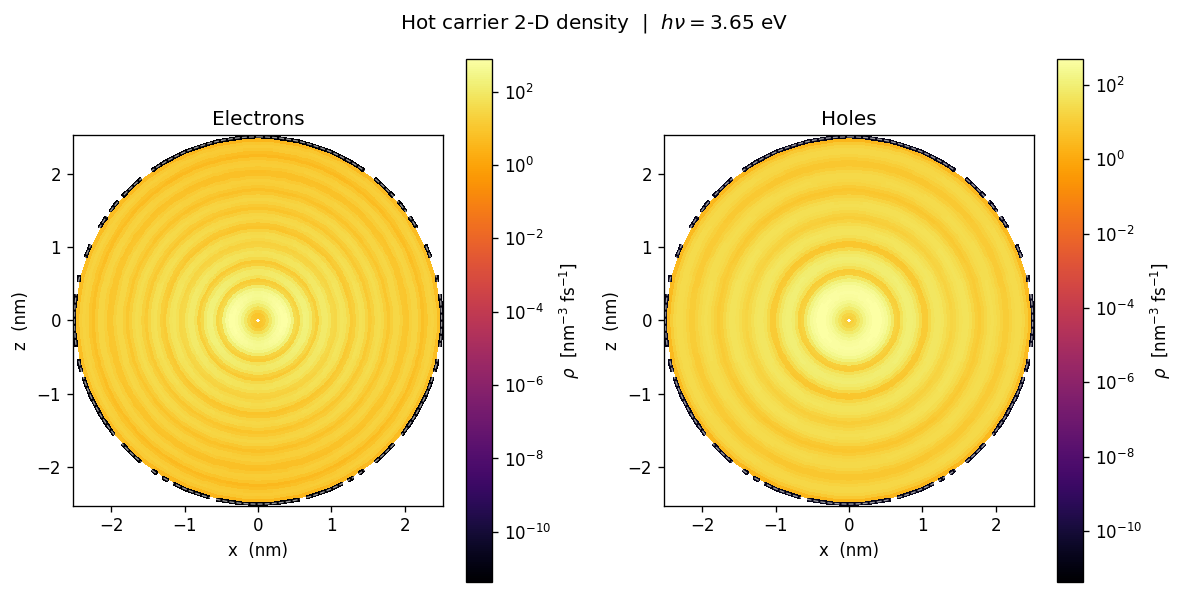

In [11]:
# ── Plot 2-D polar density ─────────────────────────────────────────────────
fig, axes = plot_2d_density(
    r2d, theta2d, rho_e_2d, rho_h_2d,
    a_nm  = a,
    hv_eV = hv_peak,
)
plt.show()

---
## Step 6 — Effect of polarization

We repeat the 2-D calculation for a **z-polarised** field (same sphere, just different $\hat{e}$).  
For $z$-polarisation the dominant dipole mode is $\ell=1$, $m=0$, so we expect  
$|Y_{10}(\theta)|^2 \propto \cos^2\theta$ — hot carriers concentrated at the **poles** ($\theta=0, \pi$).

Compare the two cross-sections to see the polarisation-driven anisotropy.

In [10]:
# ── Solve BCM with z-polarised field ──────────────────────────────────────
efield_z = EField(
    E0    = 1.0,
    k_hat = bcm.v_normalize([1, 0, 0]),   # propagation along x
    e_hat = bcm.v_normalize([0, 0, 1]),   # polarisation along z
)

Sv_z  = [bcm.Efield_coupling(sphere, efield_z)]
coef_z = np.zeros((dx_max, len(w)), dtype=complex)
for il, wi in enumerate(w):
    c, _ = bcm.solve_BCM(wi, eps_h, BCM_objects, efield_z, Gi, G0, Sv_z)
    coef_z[:, il] = c[0]

# Temporarily set z-pol coefficients on the sphere object to extract X_lm
sphere.set_coefficients(lam_um, coef_z)
X_lm_z = sphere.coef_at(lam_peak)

print('Computing 2-D polar density (z-polarised)…')
r2d_z, theta2d_z, rho_e_z, rho_h_z = hot_e_density_2d(
    a_nm    = a,
    hv_eV   = hv_peak,
    E_F     = EF,
    tau_fs  = tau_fs,
    e_state = e_states,
    X_lm    = X_lm_z,
    Pabs    = Pabs_peak,
    Nr      = 60,
    Ntheta  = 90,
)
print('Done.')

# Restore x-pol coefficients
sphere.set_coefficients(lam_um, coef)

Computing 2-D polar density (z-polarised)…


KeyboardInterrupt: 

C:\Users\Pablo\AppData\Local\Temp\ipykernel_20856\58455005.py:29: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(Xe, Ze, rho_plot, norm=norm, cmap='inferno', shading='auto')


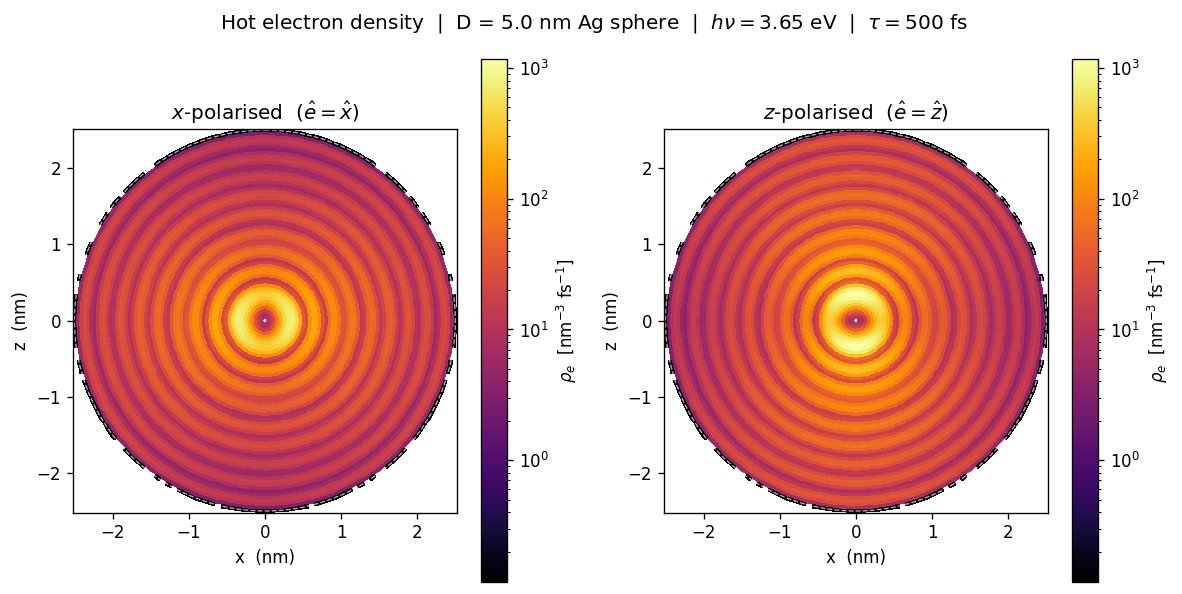

In [13]:
# ── Side-by-side comparison ────────────────────────────────────────────────
from matplotlib.colors import LogNorm

def sphere_polar_to_cart(r, theta, rho, a_nm):
    """Convert (r,θ,ρ) to (X,Z,ρ) full-circle arrays for pcolormesh."""
    R, TH = np.meshgrid(r, theta, indexing='ij')
    X = R * np.sin(TH)
    Z = R * np.cos(TH)
    X_full = np.concatenate([-X[:, ::-1],  X[:, 1:]], axis=1)
    Z_full = np.concatenate([ Z[:, ::-1],  Z[:, 1:]], axis=1)
    rho_full = np.concatenate([rho[:, ::-1], rho[:, 1:]], axis=1)
    mask = X_full**2 + Z_full**2 > a_nm**2
    return X_full, Z_full, np.where(mask, np.nan, rho_full)

Xe, Ze, re_x = sphere_polar_to_cart(r2d,   theta2d,   rho_e_2d, a)
Xe, Ze, re_z = sphere_polar_to_cart(r2d_z, theta2d_z, rho_e_z,  a)

vmax = max(np.nanmax(re_x), np.nanmax(re_z))
vmin = vmax * 1e-4
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
phi_c = np.linspace(0, 2*np.pi, 300)

for ax, rho_plot, title in [
    (ax1, re_x, r'$x$-polarised  ($\hat{e} = \hat{x}$)'),
    (ax2, re_z, r'$z$-polarised  ($\hat{e} = \hat{z}$)'),
]:
    im = ax.pcolormesh(Xe, Ze, rho_plot, norm=norm, cmap='inferno', shading='auto')
    ax.plot(a*np.sin(phi_c), a*np.cos(phi_c), 'w--', lw=0.8, alpha=0.7)
    ax.set_aspect('equal')
    ax.set_xlabel('x  (nm)')
    ax.set_ylabel('z  (nm)')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=r'$\rho_e$  [nm$^{-3}$ fs$^{-1}$]')

fig.suptitle(
    f'Hot electron density  |  D = {D} nm Ag sphere  |  '
    f'$h\\nu = {hv_peak:.2f}$ eV  |  $\\tau = {tau_fs:.0f}$ fs'
)
fig.tight_layout()
plt.show()

---
## Step 7 — Angular anisotropy index

To quantify how anisotropic the hot-carrier generation is, we define an **anisotropy index**:

$$A = \frac{\rho_e(r=a, \theta=0) - \rho_e(r=a, \theta=\pi/2)}{\rho_e(r=a, \theta=0) + \rho_e(r=a, \theta=\pi/2)}$$

$A = 0$: spherically symmetric.  $A \to 1$: all density at the poles.  $A \to -1$: all density at the equator.

In [14]:
def anisotropy_at_surface(r, theta, rho, a_nm):
    """Compute A = (rho_pole - rho_equator) / (rho_pole + rho_equator) at r ≈ a."""
    ir_surf = np.argmin(np.abs(r - a_nm * 0.95))  # just inside surface
    it_pole = np.argmin(np.abs(theta - 0))          # θ = 0
    it_equa = np.argmin(np.abs(theta - np.pi/2))    # θ = π/2
    pole = rho[ir_surf, it_pole]
    equa = rho[ir_surf, it_equa]
    if pole + equa < 1e-30:
        return 0.0
    return (pole - equa) / (pole + equa)

A_x = anisotropy_at_surface(r2d,   theta2d,   rho_e_2d, a)
A_z = anisotropy_at_surface(r2d_z, theta2d_z, rho_e_z,  a)

print(f'Anisotropy index near the surface:')
print(f'  x-polarised:  A = {A_x:+.3f}')
print(f'  z-polarised:  A = {A_z:+.3f}')
print()
print('A > 0 → pole-concentrated (z-pol dipole mode m=0)')
print('A < 0 → equator-concentrated (x-pol dipole mode |m|=1)')

Anisotropy index near the surface:
  x-polarised:  A = -0.275
  z-polarised:  A = +0.432

A > 0 → pole-concentrated (z-pol dipole mode m=0)
A < 0 → equator-concentrated (x-pol dipole mode |m|=1)


---
## Summary — Part 1

| Quantity | Function | Key output |
|---|---|---|
| Radial density $n_e(r)$ | `hot_e_dist_spatial` | Shell-by-shell generation rate |
| 3-D density $
ho_e(r)$ | `hot_e_dist_spatial` | Volume density at each radius |
| Polar density $
ho_e(r,	heta)$ | `hot_e_density_2d` | Angular anisotropy |

**Key findings for a small Ag sphere:**

1. **Radial**: High-$\ell$ states contribute near the surface; low-$\ell$, low-$n$ fill the core.
2. **Polarisation anisotropy**: $x$-pol ($|m|=1$) → equatorial concentration; $z$-pol ($m=0$) → pole concentration.
3. **Injection implication**: Resonant excitation shifts the profile toward the surface, improving extraction efficiency.

---
# Part 2 — Silver Homodimer

Two identical Ag spheres of diameter D = 5 nm separated by a gap δ = 1 nm, computed with `plytrons.HC_spatial`.

Coupling two nanospheres splits the single dipole resonance into two collective modes:

| Mode | Polarisation | Near-field | Hot-carrier pattern |
|---|---|---|---|
| **Bonding** (bright) | $E \parallel z$ (dimer axis) | Strong at gap | Poles θ = 0, π — gap-facing |
| **Transverse** | $E \perp z$ | Weak at gap | Equator θ = π/2 |

The BCM coefficients $X_{\ell m}$ automatically encode all of this coupling.

---
## Step 1 - Build the dimer

The dimer lies along the **z-axis**: Sphere 1 at $z = +d_c/2$, Sphere 2 at $z = -d_c/2$.

Two polarisations are studied:
- **Longitudinal** ($E \parallel \hat{z}$, bonding mode): large red shift, intense gap field.
- **Transverse** ($E \parallel \hat{y}$): slight blue shift, weak gap coupling.

We use $\ell_{\max} = 8$ (higher than for an isolated sphere) because near-field coupling
in the gap populates high-order multipoles that are negligible for a single sphere.


In [11]:
# -- Geometry -----------------------------------------------------------
D     = 5.0      # sphere diameter [nm]
a     = D / 2    # sphere radius   [nm]
gap   = 1.0      # surface-to-surface gap [nm]
d_c   = D + gap  # centre-to-centre distance [nm]
lmax  = 8        # multipole truncation (higher than monomer for gap coupling)
eps_h = 1.0      # host: vacuum

# -- Drude permittivity (Silver) ----------------------------------------
wp_rad = 9.07  * eV_si / hbar_si   # plasma frequency  [rad/s]
gw_rad = 0.060 * eV_si / hbar_si   # damping rate      [rad/s]
eps_b  = 4.18

def eps_drude(lam_um):
    """Drude permittivity as a function of wavelength [um]."""
    omega = 2 * np.pi * 3e14 / lam_um
    return eps_b - wp_rad**2 / (omega * (omega + 1j * gw_rad))

# -- BCM objects: dimer along z -----------------------------------------
sphere1 = BCMObject(label='Sphere1', diameter=D, lmax=lmax, eps=eps_drude,
                    position=np.array([0.0, 0.0,  d_c / 2]))
sphere2 = BCMObject(label='Sphere2', diameter=D, lmax=lmax, eps=eps_drude,
                    position=np.array([0.0, 0.0, -d_c / 2]))
BCM_objects = [sphere1, sphere2]

# -- Incident fields (propagation along x for both) ---------------------
efield_long  = EField(E0=1.0,
                      k_hat=bcm.v_normalize([1, 0, 0]),
                      e_hat=bcm.v_normalize([0, 0, 1]))   # E || z  (longitudinal)
efield_trans = EField(E0=1.0,
                      k_hat=bcm.v_normalize([1, 0, 0]),
                      e_hat=bcm.v_normalize([0, 1, 0]))   # E || y  (transverse)

print(f'Dimer axis: z,  D = {D} nm,  gap = {gap} nm,  d_c = {d_c} nm')
print(f'Sphere 1 at z = +{d_c/2:.1f} nm')
print(f'Sphere 2 at z = -{d_c/2:.1f} nm')
print(f'lmax = {lmax}')


Dimer axis: z,  D = 5.0 nm,  gap = 1.0 nm,  d_c = 6.0 nm
Sphere 1 at z = +3.0 nm
Sphere 2 at z = -3.0 nm
lmax = 8


---
## Step 2 - BCM frequency sweep

The interaction matrices $G^{\rm int}$ and $G^{\rm ext}$ are frequency-independent
and computed once. We then loop over frequencies for each polarisation separately.

For the homodimer, by inversion symmetry both spheres absorb identical power:
$P_{\rm abs}^{(1)} = P_{\rm abs}^{(2)}$. We verify this and use Sphere 1 for
all subsequent spatial analysis.


In [12]:
# -- Frequency axis ----------------------------------------------------
w       = np.linspace(2.0, 5.5, 3000) * eV_si / hbar_si   # [rad/s]
lam_um  = 2 * np.pi * 3e14 / w                             # [um]
hv_axis = w * hbar_si / eV_si                               # [eV]

# -- Precompute geometry matrices (once) --------------------------------
Gi = [bcm.Ginternal(obj) for obj in BCM_objects]
G0 = [[bcm.Gexternal(BCM_objects[i], BCM_objects[j]) for j in range(2)]
       for i in range(2)]

dx_max = lmax * (lmax + 1) + (lmax + 1) - 1

# -- Longitudinal polarisation ------------------------------------------
Sv_long   = [bcm.Efield_coupling(obj, efield_long) for obj in BCM_objects]
coef_long = [np.zeros((dx_max, len(w)), dtype=complex) for _ in range(2)]

for il, wi in enumerate(w):
    c, _ = bcm.solve_BCM(wi, eps_h, BCM_objects, efield_long, Gi, G0, Sv_long)
    coef_long[0][:, il] = c[0]
    coef_long[1][:, il] = c[1]

for i in range(2):
    BCM_objects[i].set_coefficients(lam_um, coef_long[i])
_, Pabs_long = bcm.EM_power(w, eps_h, Gi, G0, BCM_objects)
print('Longitudinal sweep done.')


Longitudinal sweep done.


Transverse sweep done.


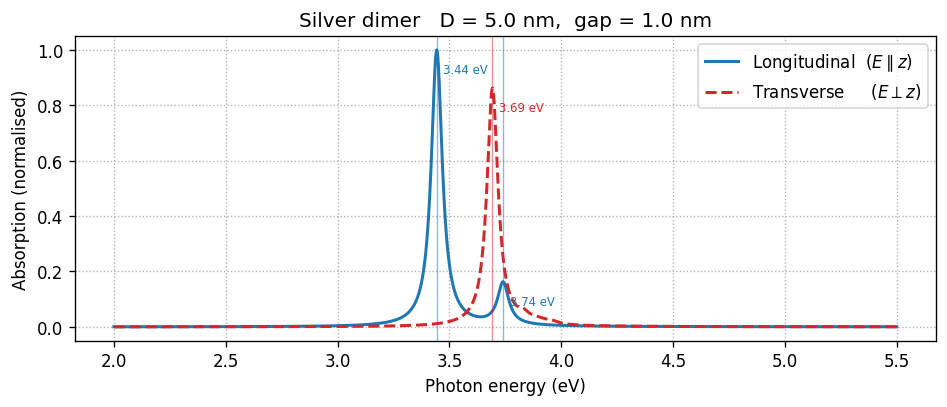

In [13]:
# -- Transverse polarisation -------------------------------------------
Sv_trans   = [bcm.Efield_coupling(obj, efield_trans) for obj in BCM_objects]
coef_trans = [np.zeros((dx_max, len(w)), dtype=complex) for _ in range(2)]

for il, wi in enumerate(w):
    c, _ = bcm.solve_BCM(wi, eps_h, BCM_objects, efield_trans, Gi, G0, Sv_trans)
    coef_trans[0][:, il] = c[0]
    coef_trans[1][:, il] = c[1]

for i in range(2):
    BCM_objects[i].set_coefficients(lam_um, coef_trans[i])
_, Pabs_trans = bcm.EM_power(w, eps_h, Gi, G0, BCM_objects)
print('Transverse sweep done.')

# -- Absorption efficiency (relative units, Sphere 1) ------------------
Qabs_long  = Pabs_long[0]  / (np.pi * a**2)
Qabs_trans = Pabs_trans[0] / (np.pi * a**2)
norm = max(Qabs_long.max(), Qabs_trans.max())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(hv_axis, Qabs_long  / norm, 'C0',   lw=1.8, label=r'Longitudinal  ($E \parallel z$)')
ax.plot(hv_axis, Qabs_trans / norm, 'C3--', lw=1.8, label=r'Transverse     ($E \perp z$)')

for Qabs, col in [(Qabs_long, 'C0'), (Qabs_trans, 'C3')]:
    pks, _ = find_peaks(Qabs / norm, height=0.05, prominence=0.02)
    for pk in pks:
        ax.axvline(hv_axis[pk], lw=0.8, alpha=0.5, color=col)
        ax.annotate(f'{hv_axis[pk]:.2f} eV',
                    xy=(hv_axis[pk], Qabs[pk] / norm),
                    xytext=(4, -14), textcoords='offset points', fontsize=7, color=col)

ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel('Absorption (normalised)')
ax.set_title(f'Silver dimer   D = {D} nm,  gap = {gap} nm')
ax.legend()
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()


---
## Step 3 — Quantum-well bound states

Both spheres share diameter D = 5 nm — identical to Part 1, so `e_states`, `lmax_qw`, and `EF` are already defined above.
We only set the lifetime used for the dimer analysis.

In [14]:
tau_fs = 500.0  # hot-carrier inelastic lifetime [fs]  (same as Part 1)

---
## Step 4 - Pick the dominant resonance for each polarisation

We identify the main absorption peak for each polarisation, extract the BCM
coefficients $X_{\ell m}$ directly from the stored coefficient arrays,
and convert the absorbed power to [eV/fs]:

$$P_{\rm abs}\,[{\rm eV/fs}] = \frac{P_{\rm abs}^{\rm BCM}}{\pi\,\varepsilon_0} \times 10^{-15}$$

Because the dimer is symmetric, $P_{\rm abs}^{(1)} = P_{\rm abs}^{(2)}$ — we verify this.


In [8]:
# -- Longitudinal: dominant peak ----------------------------------------
pks_l, _ = find_peaks(Pabs_long[0], height=Pabs_long[0].max() * 0.05)
if len(pks_l) == 0:
    pks_l = [int(Pabs_long[0].argmax())]
pk_l = pks_l[int(np.argmax(Pabs_long[0][pks_l]))]

hv_long        = hv_axis[pk_l]
X_lm_long      = coef_long[0][:, pk_l]                    # Sphere 1 BCM coefficients
Pabs_long_eVfs = Pabs_long[0][pk_l] / (np.pi * eps0) * 1e-15   # [eV/fs]

print('Longitudinal (bonding) mode:')
print(f'  hv = {hv_long:.3f} eV')
print(f'  Sphere 1 Pabs = {Pabs_long[0][pk_l]:.4g}   '
      f'Sphere 2 Pabs = {Pabs_long[1][pk_l]:.4g}  (should match by symmetry)')
print(f'  Pabs [eV/fs] = {Pabs_long_eVfs:.4g}')
print()

# -- Transverse: dominant peak ------------------------------------------
pks_t, _ = find_peaks(Pabs_trans[0], height=Pabs_trans[0].max() * 0.05)
if len(pks_t) == 0:
    pks_t = [int(Pabs_trans[0].argmax())]
pk_t = pks_t[int(np.argmax(Pabs_trans[0][pks_t]))]

hv_trans        = hv_axis[pk_t]
X_lm_trans      = coef_trans[0][:, pk_t]
Pabs_trans_eVfs = Pabs_trans[0][pk_t] / (np.pi * eps0) * 1e-15

print('Transverse mode:')
print(f'  hv = {hv_trans:.3f} eV')
print(f'  Sphere 1 Pabs = {Pabs_trans[0][pk_t]:.4g}   '
      f'Sphere 2 Pabs = {Pabs_trans[1][pk_t]:.4g}  (should match by symmetry)')
print(f'  Pabs [eV/fs] = {Pabs_trans_eVfs:.4g}')


Longitudinal (bonding) mode:
  hv = 3.444 eV
  Sphere 1 Pabs = 9.098e+17   Sphere 2 Pabs = 9.098e+17  (should match by symmetry)
  Pabs [eV/fs] = 5240

Transverse mode:
  hv = 3.692 eV
  Sphere 1 Pabs = 7.842e+17   Sphere 2 Pabs = 7.842e+17  (should match by symmetry)
  Pabs [eV/fs] = 4517


---
## Step 5 - Radial hot-carrier profiles

### Why does the bonding mode push carriers toward the surface?

In an isolated sphere, only the $\ell = 1$ dipole contributes appreciably to $|M_{fi}|^2$.
In the dimer at the bonding mode, the gap concentrates the near-field and loads energy into
high-order multipoles: $|X_{\ell m}|^2$ remains large up to $\ell \approx \ell_{\max}$.

High-$\ell$ wavefunctions $j_\ell(k_f r)$ are suppressed at small $r$ (centrifugal barrier)
and peak near $r \approx a$. Therefore:

> **Bonding mode** $\Rightarrow$ more high-$\ell$ channels active $\Rightarrow$ radial
> profile shifted toward the surface.

This surface concentration is what makes gap-coupled dimers attractive for hot-carrier
injection into a nearby acceptor material.


In [9]:
Nr = 300

# -- Longitudinal (bonding) ---------------------------------------------
r_l, n_e_l, n_h_l, rho_e_l, rho_h_l, E_all, Te_raw_l, Th_raw_l = hot_e_dist_spatial(
    a_nm    = a,
    hv_eV   = hv_long,
    E_F     = EF,
    tau_fs  = tau_fs,
    e_state = e_states,
    X_lm    = X_lm_long,
    Pabs    = Pabs_long_eVfs,
    Nr      = Nr,
)

# -- Transverse ---------------------------------------------------------
r_t, n_e_t, n_h_t, rho_e_t, rho_h_t, _, Te_raw_t, Th_raw_t = hot_e_dist_spatial(
    a_nm    = a,
    hv_eV   = hv_trans,
    E_F     = EF,
    tau_fs  = tau_fs,
    e_state = e_states,
    X_lm    = X_lm_trans,
    Pabs    = Pabs_trans_eVfs,
    Nr      = Nr,
)

# -- Normalisation check: integral of n_e should equal sum of Te_raw ---
print(f'Longitudinal: int n_e dr = {np.trapz(n_e_l, r_l):.4g}   Sum Te_raw = {Te_raw_l.sum():.4g}')
print(f'Transverse:   int n_e dr = {np.trapz(n_e_t, r_t):.4g}   Sum Te_raw = {Te_raw_t.sum():.4g}')


c:\users\pablo\proyectos\plytrons\plytrons\hot_carriers.py:224: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi_2_block = _M_transition_squared(lf, li, a_nm, X_lm, state_lf, state_li)
c:\users\pablo\proyectos\plytrons\plytrons\hot_carriers.py:224: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi_2_block = _M_transition_squared(lf, li, a_nm, X_lm, state_lf, state_li)
c:\users\pablo\proyectos\plytrons\plytrons\HC_spatial.py:123: NumbaWarning: Cannot cache compiled function "_radial_density_kernel" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @nb.njit(cache=True, fastmath=True)


Longitudinal: int n_e dr = 1585   Sum Te_raw = 1585
Transverse:   int n_e dr = 1464   Sum Te_raw = 1464


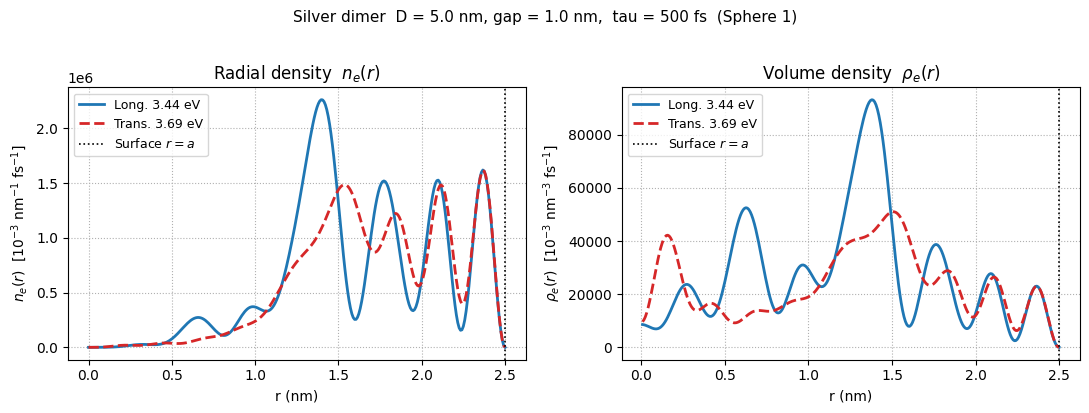

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(r_l, n_e_l * 1e3, 'C0',   lw=2, label=f'Long. {hv_long:.2f} eV')
ax.plot(r_t, n_e_t * 1e3, 'C3--', lw=2, label=f'Trans. {hv_trans:.2f} eV')
ax.axvline(a, ls=':', lw=1.2, color='k', label='Surface $r=a$')
ax.set_xlabel('r (nm)')
ax.set_ylabel(r'$n_e(r)$  [$10^{-3}$ nm$^{-1}$ fs$^{-1}$]')
ax.set_title(r'Radial density  $n_e(r)$')
ax.legend(fontsize=9)
ax.grid(True, ls=':')

ax = axes[1]
ax.plot(r_l[1:], rho_e_l[1:] * 1e3, 'C0',   lw=2, label=f'Long. {hv_long:.2f} eV')
ax.plot(r_t[1:], rho_e_t[1:] * 1e3, 'C3--', lw=2, label=f'Trans. {hv_trans:.2f} eV')
ax.axvline(a, ls=':', lw=1.2, color='k', label='Surface $r=a$')
ax.set_xlabel('r (nm)')
ax.set_ylabel(r'$\rho_e(r)$  [$10^{-3}$ nm$^{-3}$ fs$^{-1}$]')
ax.set_title(r'Volume density  $\rho_e(r)$')
ax.legend(fontsize=9)
ax.grid(True, ls=':')

fig.suptitle(
    f'Silver dimer  D = {D} nm, gap = {gap} nm,  tau = {tau_fs:.0f} fs  (Sphere 1)',
    y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


---
### Breakdown by angular momentum $\ell$

We decompose $n_e(r) = \sum_\ell n_e^\ell(r)$ to identify which multipole
channels are responsible for the surface concentration at the bonding mode.

At the bonding mode the gap drives amplitude into high-$\ell$ states.
Those states have $j_\ell(k_f r)$ peaked near $r = a$, explaining the
surface-concentrated profile.


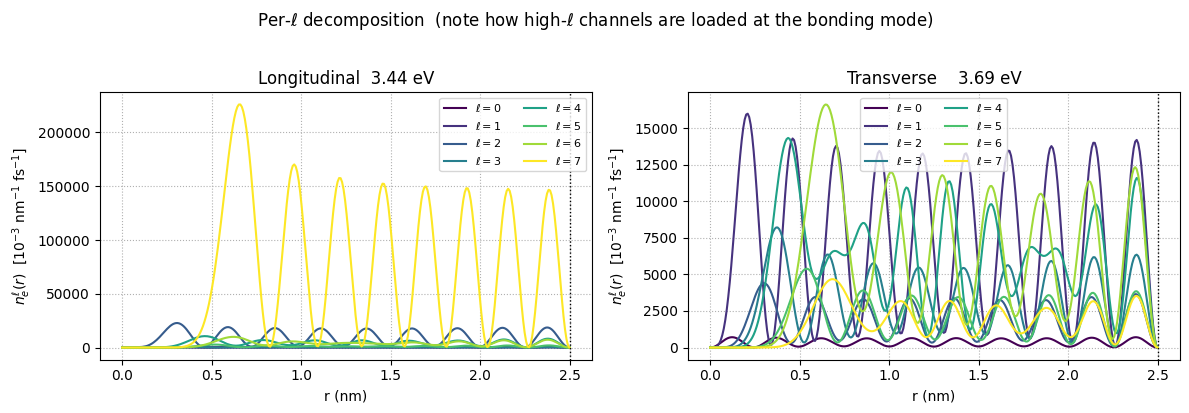

In [11]:
from plytrons.quantum_well import js_real, ke

# Build l-ordered state map (same ordering as hot_e_dist returns Te_raw)
E_lo, l_lo, A2_lo = [], [], []
for l in range(lmax_qw):
    for n in range(e_states[l].Eb.size):
        E_lo.append(float(e_states[l].Eb[n].real))
        l_lo.append(l)
        A = e_states[l].A[n]
        A2_lo.append(float((A * A.conj()).real))
E_lo  = np.array(E_lo)
l_lo  = np.array(l_lo, dtype=int)
A2_lo = np.array(A2_lo)

n_colors = min(lmax_qw, 8)
colors   = plt.cm.viridis(np.linspace(0, 1, n_colors))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, Te_raw_p, r_p in [
        (axes[0], f'Longitudinal  {hv_long:.2f} eV', Te_raw_l, r_l),
        (axes[1], f'Transverse    {hv_trans:.2f} eV', Te_raw_t, r_t),
    ]:
    for lv in range(n_colors):
        mask = (l_lo == lv)
        if not mask.any():
            continue
        contrib = np.zeros_like(r_p)
        for f in np.where(mask)[0]:
            if E_lo[f] < EF:
                continue
            k_f = float(ke(E_lo[f]))
            jl2 = js_real(lv, k_f * r_p) ** 2
            contrib += Te_raw_p[f] * A2_lo[f] * jl2 * r_p**2
        ax.plot(r_p, contrib * 1e3, color=colors[lv], lw=1.5, label=rf'$\ell={lv}$')

    ax.axvline(a, ls=':', lw=1, color='k')
    ax.set_xlabel('r (nm)')
    ax.set_ylabel(r'$n_e^\ell(r)$  [$10^{-3}$ nm$^{-1}$ fs$^{-1}$]')
    ax.set_title(title)
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, ls=':')

fig.suptitle(
    r'Per-$\ell$ decomposition  '
    r'(note how high-$\ell$ channels are loaded at the bonding mode)',
    y=1.02)
plt.tight_layout()
plt.show()


---
## Step 6 - 2-D polar density $\rho_e(r, \theta)$

The radial profile averages over all $m$ sub-levels.
The incident polarisation breaks that symmetry through the selection rule
$\Delta m = m_{\rm photon}$:

| Polarisation | Dominant $m$ | $|Y_{\ell m}(\theta)|^2$ | Hot-carrier location |
|---|---|---|---|
| $E \parallel z$ (long.) | $m = 0$ | $\propto P_\ell^2(\cos\theta)$ | Poles $\theta=0,\pi$ |
| $E \parallel y$ (trans.) | $m = \pm 1$ | $\propto \sin^2\theta$ | Equator $\theta=\pi/2$ |

**Sphere 1 local frame**: the dimer gap faces the $-z$ direction (bottom of the plot,
$\theta = \pi$).
For $m=0$ modes both poles are enhanced equally, so **both** gap-facing
and far surfaces receive hot carriers at the bonding mode.


In [12]:
Nr_2d  = 60
Ntheta = 90

print('Computing 2-D density (longitudinal)...')
r2d_l, th2d_l, rho2d_e_l, rho2d_h_l = hot_e_density_2d(
    a_nm=a,  hv_eV=hv_long,  E_F=EF, tau_fs=tau_fs,
    e_state=e_states, X_lm=X_lm_long,  Pabs=Pabs_long_eVfs,
    Nr=Nr_2d, Ntheta=Ntheta)
print('Done.')

print('Computing 2-D density (transverse)...')
r2d_t, th2d_t, rho2d_e_t, rho2d_h_t = hot_e_density_2d(
    a_nm=a,  hv_eV=hv_trans, E_F=EF, tau_fs=tau_fs,
    e_state=e_states, X_lm=X_lm_trans, Pabs=Pabs_trans_eVfs,
    Nr=Nr_2d, Ntheta=Ntheta)
print('Done.')

# Normalisation: 2pi int int rho r^2 sin(theta) dr dtheta = Sum Te_raw
def _check_norm(r, theta, rho):
    R2, TH2 = np.meshgrid(r, theta, indexing='ij')
    return 2 * np.pi * np.trapz(np.trapz(rho * R2**2 * np.sin(TH2), theta, axis=1), r)

print(f'Long.  norm = {_check_norm(r2d_l, th2d_l, rho2d_e_l):.4g}   '
      f'(Sum Te_raw = {Te_raw_l.sum():.4g})')
print(f'Trans. norm = {_check_norm(r2d_t, th2d_t, rho2d_e_t):.4g}   '
      f'(Sum Te_raw = {Te_raw_t.sum():.4g})')


Computing 2-D density (longitudinal)...


c:\users\pablo\proyectos\plytrons\plytrons\HC_spatial.py:398: RuntimeWarning: overflow encountered in exp
  fd  = 1.0 / (np.exp((E_m - E_F) / (k_B * T0)) + 1.0)


Done.
Computing 2-D density (transverse)...
Done.
Long.  norm = 1585   (Sum Te_raw = 1585)
Trans. norm = 1464   (Sum Te_raw = 1464)


C:\Users\Pablo\AppData\Local\Temp\ipykernel_20648\946587612.py:29: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(Xg, Zg, Rg, cmap='inferno', norm=norm, shading='auto')
C:\Users\Pablo\AppData\Local\Temp\ipykernel_20648\946587612.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


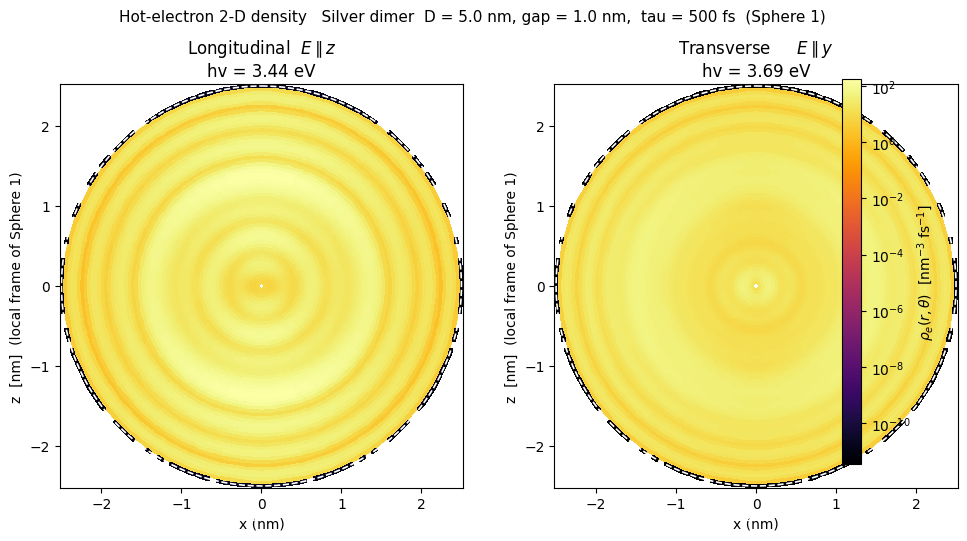

In [13]:
from matplotlib.colors import LogNorm

def _to_cart_full(r, theta, rho, a_nm):
    """Fold (r, theta) half-plane into a full circle in (x, z) Cartesian."""
    R, TH = np.meshgrid(r, theta, indexing='ij')
    X = R * np.sin(TH)
    Z = R * np.cos(TH)
    Xf = np.concatenate([-X[:, ::-1],  X[:, 1:]], axis=1)
    Zf = np.concatenate([ Z[:, ::-1],  Z[:, 1:]], axis=1)
    Rf = np.concatenate([rho[:, ::-1], rho[:, 1:]], axis=1)
    Rf = np.where(Xf**2 + Zf**2 > a_nm**2, np.nan, Rf)
    return Xf, Zf, Rf

Xl, Zl, Rl = _to_cart_full(r2d_l, th2d_l, rho2d_e_l, a)
Xt, Zt, Rt = _to_cart_full(r2d_t, th2d_t, rho2d_e_t, a)

v_lo = min(np.nanmin(Rl[Rl > 0]), np.nanmin(Rt[Rt > 0]))
v_hi = max(np.nanmax(Rl),         np.nanmax(Rt))
norm = LogNorm(vmin=v_lo, vmax=v_hi)

th_circ = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, Xg, Zg, Rg, hv_v, pol_label in [
        (axes[0], Xl, Zl, Rl, hv_long,  r'Longitudinal  $E \parallel z$'),
        (axes[1], Xt, Zt, Rt, hv_trans, r'Transverse     $E \parallel y$'),
    ]:
    im = ax.pcolormesh(Xg, Zg, Rg, cmap='inferno', norm=norm, shading='auto')
    ax.plot(a * np.sin(th_circ), a * np.cos(th_circ), 'w--', lw=1.2)
    # Mark gap direction (gap is below Sphere 1 at z_local = -a)
    ax.text(0, -(a + 0.3), 'gap', ha='center', va='top',
            color='white', fontsize=8, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlabel('x (nm)')
    ax.set_ylabel('z  [nm]  (local frame of Sphere 1)')
    ax.set_title(f'{pol_label}\nhv = {hv_v:.2f} eV')

plt.colorbar(im, ax=axes, label=r'$\rho_e(r,\theta)$  [nm$^{-3}$ fs$^{-1}$]',
             fraction=0.04, pad=0.02)
fig.suptitle(
    f'Hot-electron 2-D density   Silver dimer  D = {D} nm, gap = {gap} nm,  '
    f'tau = {tau_fs:.0f} fs  (Sphere 1)',
    y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


---
## Step 7 - Angular anisotropy index

We quantify the pole-vs-equator asymmetry at the sphere surface:

$$A = \frac{\rho_e(r \approx a,\; \theta=0) - \rho_e(r \approx a,\; \theta=\pi/2)}
           {\rho_e(r \approx a,\; \theta=0) + \rho_e(r \approx a,\; \theta=\pi/2)}$$

$A = +1$: all density at the poles.
$A = -1$: all density at the equator.
$A = 0$: isotropic.

Expected: $A > 0$ for the longitudinal mode (poles), $A < 0$ for the transverse mode (equator).


In [14]:
def anisotropy_at_surface(r, theta, rho, a_nm, frac=0.95):
    """A = (rho_pole - rho_equator) / (rho_pole + rho_equator) just inside the surface."""
    ir   = int(np.argmin(np.abs(r - a_nm * frac)))
    it_p = int(np.argmin(np.abs(theta)))              # theta = 0 (pole)
    it_e = int(np.argmin(np.abs(theta - np.pi / 2)))  # theta = pi/2 (equator)
    pole = rho[ir, it_p]
    equa = rho[ir, it_e]
    if pole + equa < 1e-30:
        return 0.0
    return (pole - equa) / (pole + equa)

A_long  = anisotropy_at_surface(r2d_l, th2d_l, rho2d_e_l, a)
A_trans = anisotropy_at_surface(r2d_t, th2d_t, rho2d_e_t, a)

print('Angular anisotropy index  A  (at r = 0.95 a)')
print()
print(f'  Longitudinal (bonding)  A = {A_long:+.3f}  ->  '
      f'{"pole-concentrated" if A_long > 0 else "equatorial"}')
print(f'  Transverse              A = {A_trans:+.3f}  ->  '
      f'{"pole-concentrated" if A_trans > 0 else "equatorial"}')
print()
print('For the symmetric dimer, m=0 (longitudinal) enhances theta=0 and theta=pi equally.')
print('The gap-facing (theta=pi) and far (theta=0) poles are indistinguishable by symmetry.')
print('The key physical contrast is pole vs equator, captured by A.')


Angular anisotropy index  A  (at r = 0.95 a)

  Longitudinal (bonding)  A = +0.445  ->  pole-concentrated
  Transverse              A = -0.171  ->  equatorial

For the symmetric dimer, m=0 (longitudinal) enhances theta=0 and theta=pi equally.
The gap-facing (theta=pi) and far (theta=0) poles are indistinguishable by symmetry.
The key physical contrast is pole vs equator, captured by A.


---
## Summary

| | Longitudinal (bonding) | Transverse |
|---|---|---|
| **Photon energy** | red-shifted vs monomer | near monomer value |
| **Gap near-field** | strong | weak |
| **Active $\ell$ channels** | $1 \ldots \ell_{\max}$ (many) | dominated by $\ell=1$ |
| **Radial profile** | surface-concentrated | broader, more uniform |
| **Angular pattern** | poles ($\theta=0, \pi$) | equator ($\theta=\pi/2$) |
| **Anisotropy $A$** | $> 0$ (poles) | $< 0$ (equator) |

### Architecture

```
bcm_sphere.py    Ginternal / Gexternal / solve_BCM  -->  X_lm(omega)
quantum_well.py  get_bound_states / e_state_assembly -->  e_states
                                                         |
HC_spatial.py    hot_e_dist_spatial  -->  n_e(r), rho_e(r)       (radial)
                 hot_e_density_2d    -->  rho_e(r, theta)         (polar map)
```

The gap-coupling physics (multipole loading, near-field enhancement) lives entirely
inside $X_{\ell m}$ — computed by the BCM.
`HC_spatial.py` only weights the pre-computed hot-carrier rates by
$|\psi_f(r, \theta)|^2 = |A_f|^2 |j_{\ell_f}(k_f r)|^2 |Y_{\ell_f m_f}(\theta)|^2$.
